# Візуалізації — Python + matplotlib/seaborn

Цей ноутбук відповідає на 6 аналітичних питань з `00_intro.ipynb` у графічному форматі. Дані завантажуються напряму з PostgreSQL через SQLAlchemy — кожен графік супроводжується SQL-запитом та висновком.

Готові графіки зберігаються у папці `images/` і використовуються в README проєкту.

| Графік | Аналітичне питання |
|---|---|
| 1 | Динаміка замовлень по місяцях (Q1) |
| 2 | Топ-10 категорій за доходом (Q2) |
| 3 | Середній час доставки по штатах (Q3) |
| 4 | Розподіл оцінок відгуків (Q4) |
| 5 | Залежність оцінки від часу доставки (Q8) |
| 6 | Розподіл способів оплати (Q7) |

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.config import get_engine

engine = get_engine()

# Папка для збереження графіків
IMAGES_DIR = Path.cwd().parent / "images"
IMAGES_DIR.mkdir(exist_ok=True)

# Глобальний стиль
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

print("✓ Підключення до БД встановлено")
print(f"✓ Графіки зберігатимуться у: {IMAGES_DIR}")

✓ Підключення до БД встановлено
✓ Графіки зберігатимуться у: /Users/kiichenko_vladyslav/DA Study/olist-ecommerce-analysis/images


### Графік 1: Динаміка замовлень по місяцях

**Q1:** Яка динаміка кількості замовлень по місяцях — чи росте платформа?  
Дані: `purchased_at` з таблиці `orders`, агреговані по місяцях через `DATE_TRUNC`.

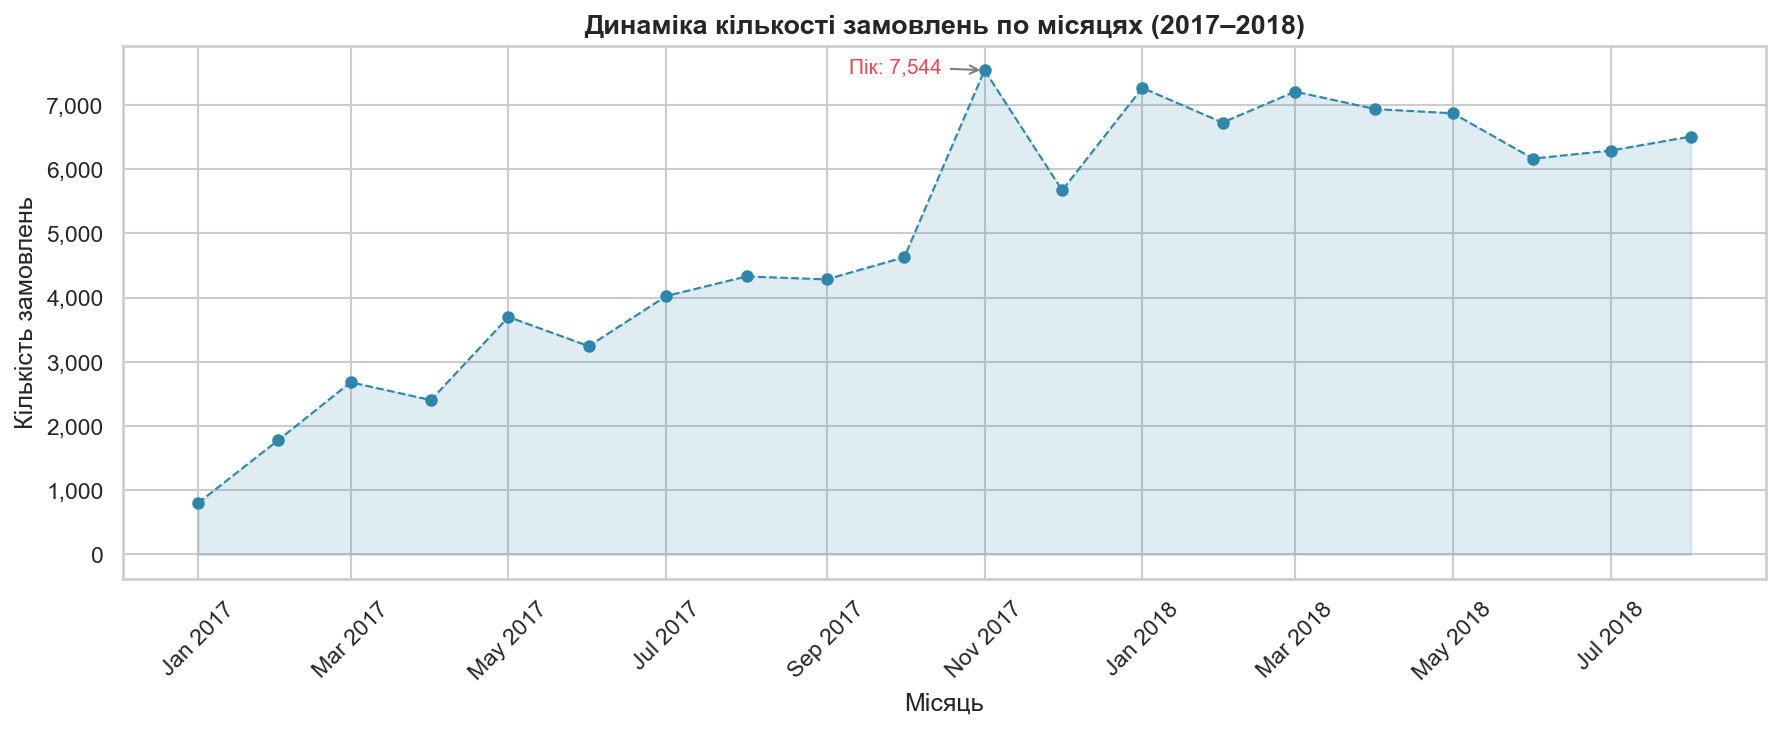

✓ Збережено: chart_01_orders_by_month.png


In [2]:
sql_q1 = """
    SELECT
        DATE_TRUNC('month', purchased_at)::date AS month,
        COUNT(*) AS order_count
    FROM orders
    WHERE purchased_at BETWEEN '2017-01-01' AND '2018-08-31'
    GROUP BY month
    ORDER BY month;
"""

df_q1 = pd.read_sql(sql_q1, engine)
df_q1["month"] = pd.to_datetime(df_q1["month"])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
        df_q1["month"], 
        df_q1["order_count"],
        marker="o", 
        linewidth=1,
        linestyle='--', 
        markersize=5, 
        color="#2E86AB"
)

ax.fill_between(
        df_q1["month"], 
        df_q1["order_count"], 
        alpha=0.15, 
        color="#2E86AB"
)

max_idx = df_q1["order_count"].idxmax()
ax.annotate(
        f'Пік: {df_q1.loc[max_idx, "order_count"]:,}',
        xy=(df_q1.loc[max_idx, "month"], df_q1.loc[max_idx, "order_count"]),
        xytext=(-65, -1), 
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=10, 
        color="#E84855"
)

ax.set_title("Динаміка кількості замовлень по місяцях (2017–2018)")
ax.set_xlabel("Місяць")
ax.set_ylabel("Кількість замовлень")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_01_orders_by_month.png")
plt.show()

print("✓ Збережено: chart_01_orders_by_month.png")

### Висновок

Платформа демонструє стабільне зростання протягом 2017 року з піком у **листопаді 2017** (7,544 замовлення) — підтверджений ефект **Black Friday**.  
Грудень 2017 показав природний спад після піку розпродажів — типова поведінка e-commerce після Black Friday у всіх ринках.  
З січня 2018 платформа вийшла на стабільне плато ~6,000–7,000 замовлень на місяць за рахунок стабільного припливу нових клієнтів.

### Графік 2: Топ-10 категорій за доходом

**Q2:** Які топ-10 категорій генерують найбільший дохід?  
Дані: сума `price` з `order_items`, приєднана до `products` через `product_id`.

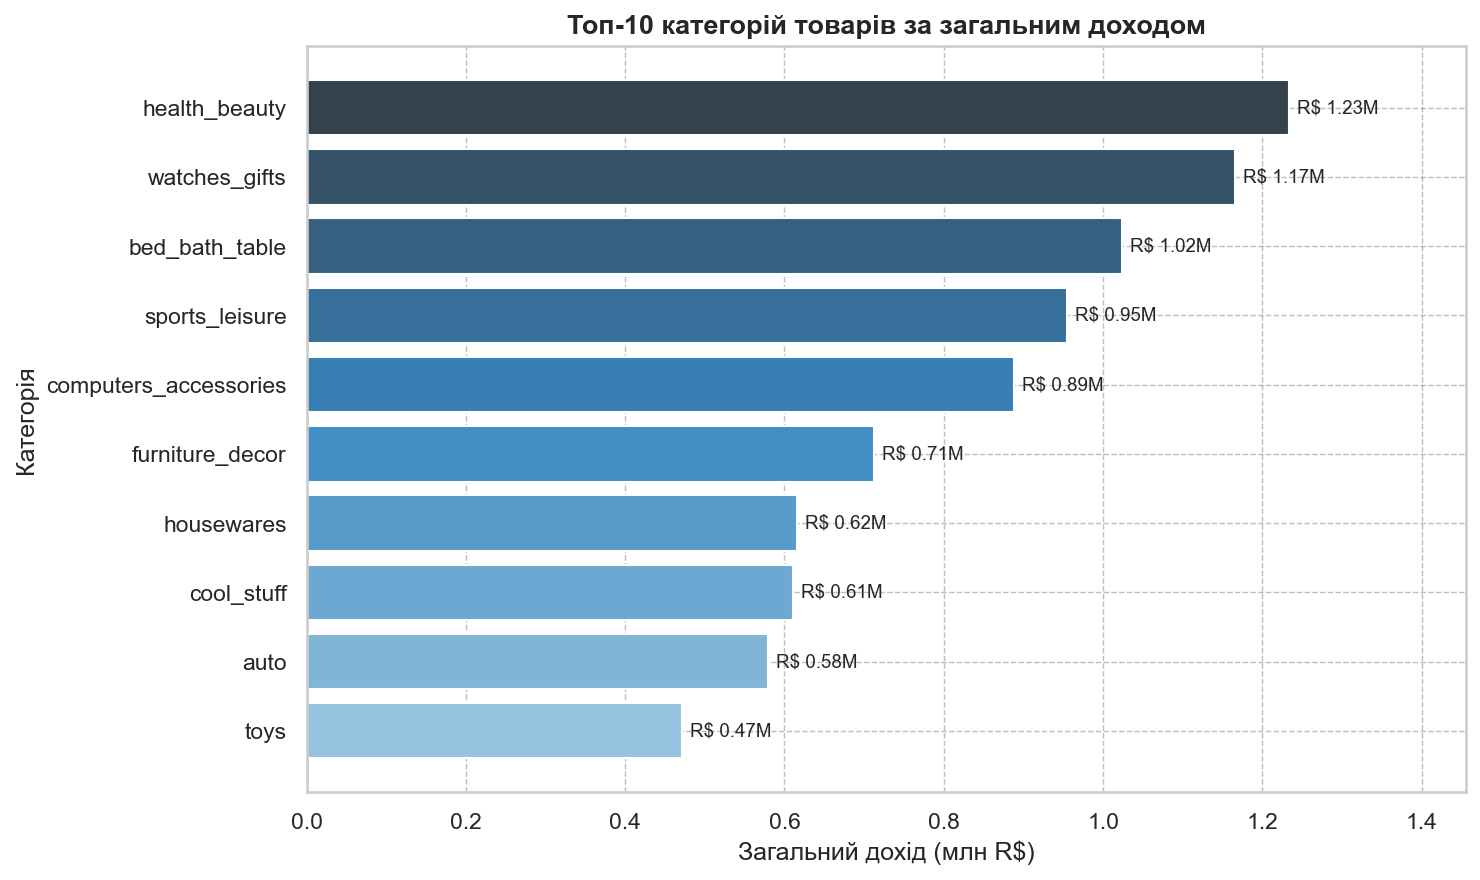

✓ Збережено: chart_02_top10_categories_revenue.png


In [3]:
sql_q2 = """
    SELECT
        p.category_name_english AS category,
        ROUND(SUM(oi.price)::numeric, 2) AS total_revenue
    FROM order_items AS oi
    JOIN products AS p 
        ON oi.product_id = p.product_id
    JOIN orders AS o
        ON oi.order_id = o.order_id
    WHERE true
        AND o.status = 'delivered'
        AND p.category_name_english != 'unknown'
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10;
"""

df_q2 = pd.read_sql(sql_q2, engine)
df_q2["total_revenue_m"] = df_q2["total_revenue"] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
            df_q2["category"][::-1], 
            df_q2["total_revenue_m"][::-1],
            color=sns.color_palette("Blues_d", len(df_q2))
)

for bar, val in zip(bars, df_q2["total_revenue_m"][::-1]):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f"R$ {val:.2f}M", 
        va="center", 
        fontsize=9
    )

ax.set_title("Топ-10 категорій товарів за загальним доходом")
ax.set_xlabel("Загальний дохід (млн R$)")
ax.set_ylabel("Категорія")
ax.set_xlim(0, df_q2["total_revenue_m"].max() * 1.18)
ax.grid(
    True,
    axis="both",
    linestyle="--",
    linewidth=0.7,
    color="gray",
    alpha=0.5
)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_02_top10_categories_revenue.png")
plt.show()

print("✓ Збережено: chart_02_top10_categories_revenue.png")

### Висновок

Категорія **health_beauty** лідирує з доходом R$ 1.23M — попит на косметику та товари для здоров'я стабільно високий на бразильському ринку.  
Топ-3 категорії (health_beauty, watches_gifts, bed_bath_table) разом генерують близько **R$ 3.42M** — майже 45% від сумарного доходу топ-10.  
Рекомендація: пріоритизувати залучення нових продавців саме в ці категорії для збільшення GMV платформи.

### Графік 3: Середній час доставки по штатах

**Q3:** Який середній час доставки по штатах і де найгірша логістика?  
Дані: різниця між `delivered_to_customer_at` і `purchased_at` з `orders`, приєднана до `customers` через `customer_id` для отримання штату клієнта.

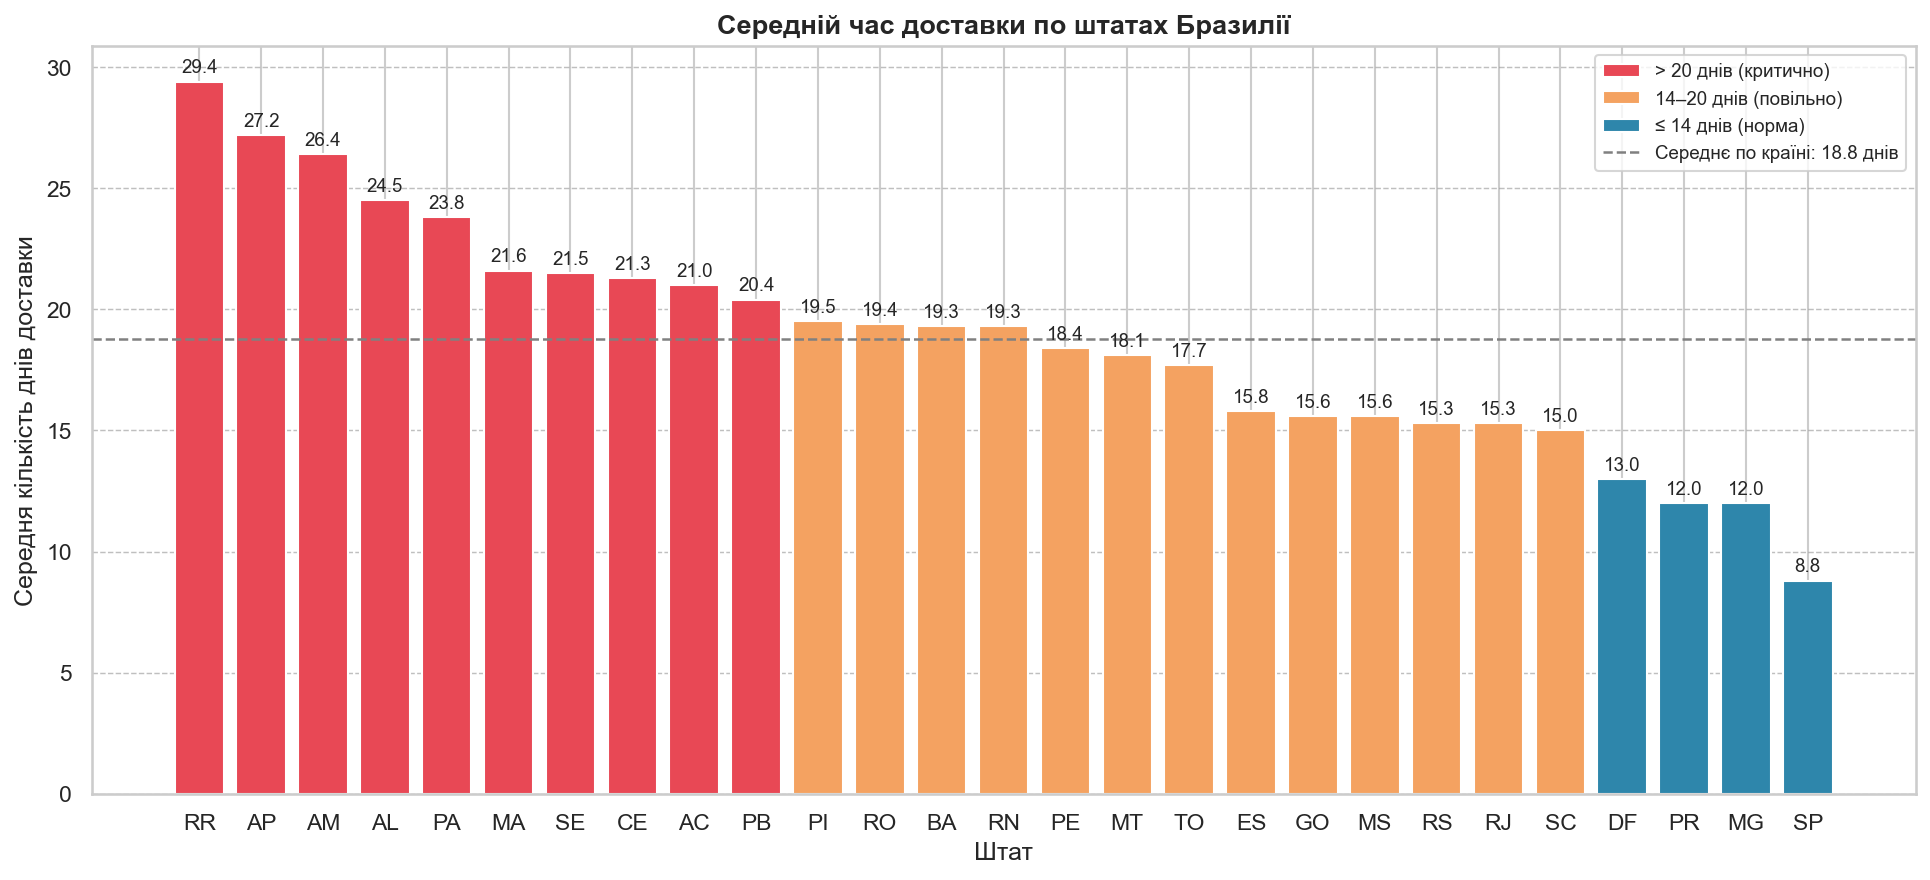

✓ Збережено: chart_03_delivery_days_by_state.png


In [4]:
sql_q3 = """
    SELECT
        c.state,
        ROUND(AVG(
            EXTRACT(EPOCH FROM (o.delivered_to_customer_at - o.purchased_at)) 
            / 86400
        )::numeric, 1) AS avg_delivery_days,
        COUNT(*) AS order_count
    FROM orders AS o
    JOIN customers AS c 
        ON o.customer_id = c.customer_id
    WHERE true
        AND o.delivered_to_customer_at IS NOT NULL
      AND o.status = 'delivered'
    GROUP BY c.state
    ORDER BY avg_delivery_days DESC;
"""

df_q3 = pd.read_sql(sql_q3, engine)

fig, ax = plt.subplots(figsize=(13, 6))

colors = ["#E84855" if d > 20 else "#F4A261" if d > 14 else "#2E86AB"
          for d in df_q3["avg_delivery_days"]]

bars = ax.bar(
    df_q3["state"], 
    df_q3["avg_delivery_days"], 
    color=colors, 
    edgecolor="white"
)

# Значення над кожним стовпчиком
for bar, val in zip(bars, df_q3["avg_delivery_days"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
        f"{val:.1f}", 
        ha="center", 
        va="bottom", 
        fontsize=9
    )

# Горизонтальна лінія — орієнтир
ax.axhline(
    y=df_q3["avg_delivery_days"].mean(), 
    color="gray",
    linestyle="--", 
    linewidth=1.2,
    label=f"Середнє по країні: {df_q3['avg_delivery_days'].mean():.1f} днів"
)

ax.set_title("Середній час доставки по штатах Бразилії")
ax.set_xlabel("Штат")
ax.set_ylabel("Середня кількість днів доставки")
ax.legend(fontsize=10)

# Легенда кольорів
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#E84855", label="> 20 днів (критично)"),
    Patch(facecolor="#F4A261", label="14–20 днів (повільно)"),
    Patch(facecolor="#2E86AB", label="≤ 14 днів (норма)"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.2,
           label=f"Середнє по країні: {df_q3['avg_delivery_days'].mean():.1f} днів"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_03_delivery_days_by_state.png")
plt.show()

print("✓ Збережено: chart_03_delivery_days_by_state.png")

### Висновок

Штат **RR (Roraima)** має найгіршу логістику — середній час доставки 29.4 днів, що майже вдвічі перевищує середнє по країні (~19 днів).  
Загалом **більшість штатів (>70%)** знаходяться в зоні "повільно" або "критично" — це системна проблема логістики, а не виняток.  
Лише 4 штати (DF, PR, MG, SP) укладаються в норму ≤14 днів — всі розташовані на півдні або в центрі країни, поблизу великих логістичних хабів.

### Графік 4: Розподіл оцінок відгуків

**Q4:** Як розподіляються оцінки відгуків і який % незадоволених клієнтів?  
Дані: `score` з таблиці `order_reviews` (98,410 відгуків після дедуплікації).

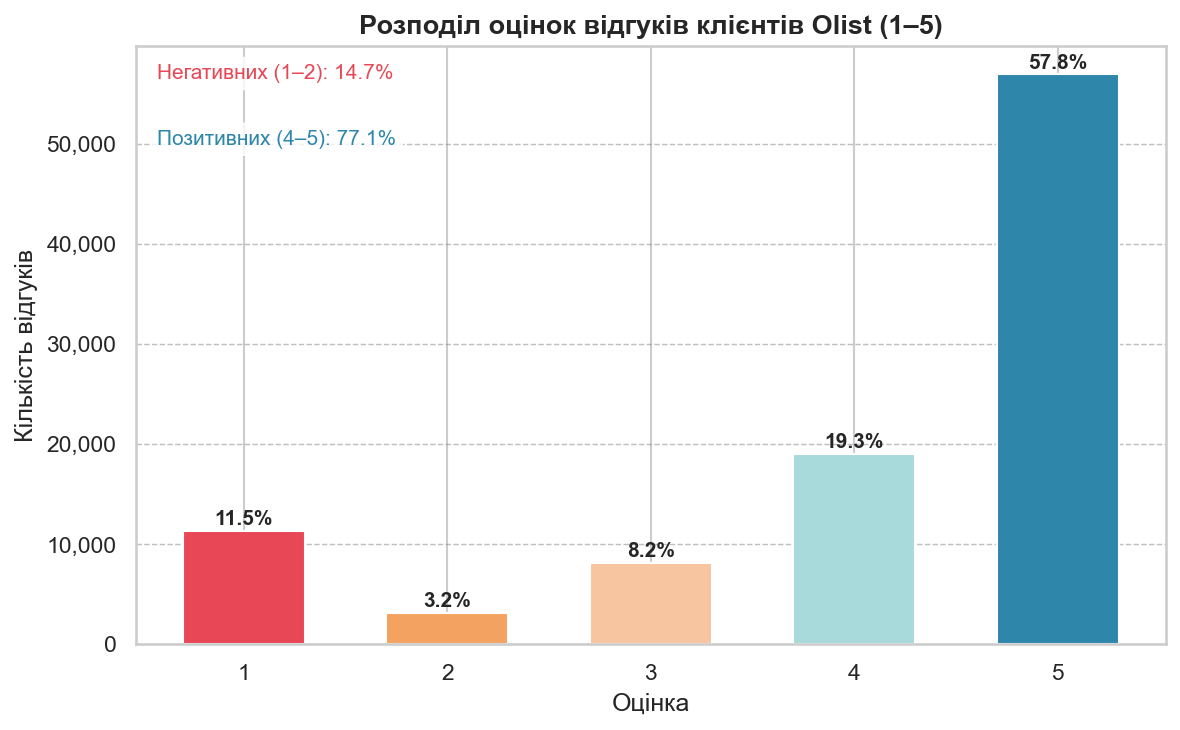

✓ Збережено: chart_04_review_scores_distribution.png


In [5]:
sql_q4 = """
    SELECT
        score,
        COUNT(*) AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM order_reviews
    GROUP BY score
    ORDER BY score;
"""

df_q4 = pd.read_sql(sql_q4, engine)

score_colors = {1: "#E84855", 2: "#F4A261", 3: "#F7C59F", 4: "#A8DADC", 5: "#2E86AB"}
colors = [score_colors[s] for s in df_q4["score"]]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
            df_q4["score"].astype(str), 
            df_q4["review_count"],
            color=colors, 
            edgecolor="white", 
            width=0.6
)

for bar, (_, row) in zip(bars, df_q4.iterrows()):
    ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f"{row['pct']}%", 
            ha="center", 
            va="bottom", 
            fontsize=10, 
            fontweight="bold"
    )

ax.set_title("Розподіл оцінок відгуків клієнтів Olist (1–5)")
ax.set_xlabel("Оцінка")
ax.set_ylabel("Кількість відгуків")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Підписуємо % негативних (1-2)
neg_pct = df_q4[df_q4["score"] <= 2]["pct"].sum()
pos_pct = df_q4[df_q4["score"] >= 4]["pct"].sum()

ax.text(
        0.02, 
        0.97, 
        f"Негативних (1–2): {neg_pct:.1f}%",
        transform=ax.transAxes, 
        fontsize=10, 
        color="#E84855",
        va="top", 
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.text(
        0.02, 
        0.86, 
        f"Позитивних (4–5): {pos_pct:.1f}%",
        transform=ax.transAxes, 
        fontsize=10, 
        color="#2E86AB",
        va="top", 
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.grid(True, axis="y", linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_04_review_scores_distribution.png")
plt.show()

print("✓ Збережено: chart_04_review_scores_distribution.png")

### Висновок

Розподіл має чітку **J-подібну форму** — типову для e-commerce платформ: клієнти залишають відгуки переважно в крайніх випадках (дуже задоволені або незадоволені).  
**57.8%** усіх відгуків — оцінка 5, що свідчить про загалом позитивний досвід.  
Проте **14.7% негативних відгуків (1–2)** — сигнал для роботи з якістю сервісу, враховуючи що більшість з них (11.5%) — це найнижча оцінка 1.

### Графік 5: Залежність оцінки від часу доставки

**Q8:** Чи впливає час доставки на оцінку клієнта?  
Замовлення розбиті на 4 бакети за часом доставки (1–3 днів, 4–7, 8–14, 15+). Для кожного бакету розраховано середню оцінку та кількість замовлень.

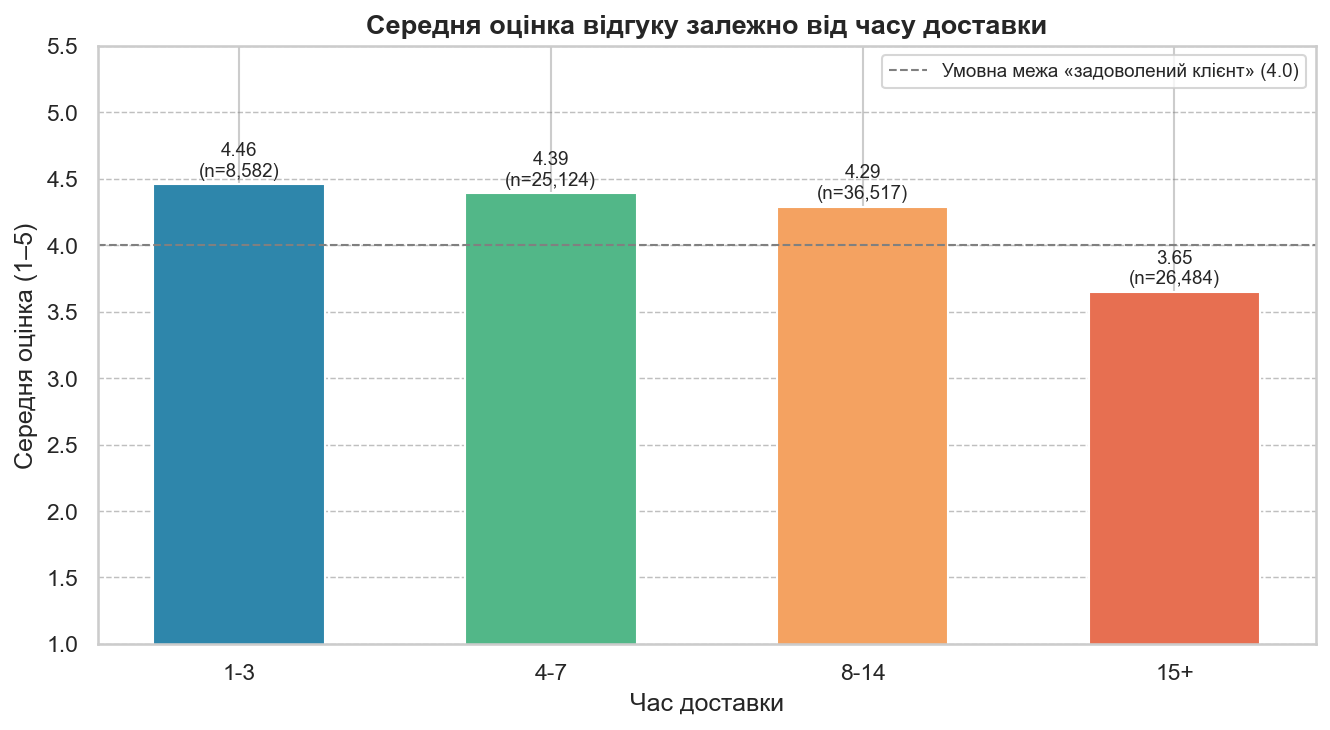

✓ Збережено: chart_05_score_vs_delivery_time.png


In [6]:
sql_q5 = """
    WITH delivered_orders AS (
        SELECT
            o.order_id,
            o.customer_id,
            ROUND(EXTRACT(EPOCH FROM (o.delivered_to_customer_at - o.purchased_at))::numeric / 86400, 2) AS total_days
        FROM orders AS o
        WHERE true
            AND o.status = 'delivered'
            AND o.delivered_to_customer_at IS NOT NULL
            AND o.delivered_to_customer_at >= o.purchased_at
    )
    SELECT
        CASE
            WHEN dor.total_days < 4 THEN '1-3'
            WHEN dor.total_days < 8 THEN '4-7'
            WHEN dor.total_days < 15 THEN '8-14'
            ELSE '15+'
        END AS delivery_bucket,
        COUNT(dor.order_id) AS order_count,
        ROUND(AVG(orv.score), 2) AS avg_score
    FROM delivered_orders AS dor
    LEFT JOIN order_reviews AS orv
        ON dor.order_id = orv.order_id
    GROUP BY delivery_bucket
    ORDER BY MIN(dor.total_days);
"""
df_q5 = pd.read_sql(sql_q5, engine)

bucket_colors = ["#2E86AB", "#52B788", "#F4A261", "#E76F51", "#E84855"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
            df_q5["delivery_bucket"], 
            df_q5["avg_score"],
            color=bucket_colors, 
            edgecolor="white", 
            width=0.55
)

for bar, (_, row) in zip(bars, df_q5.iterrows()):
    ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f"{row['avg_score']:.2f}\n(n={row['order_count']:,})",
            ha="center", 
            va="bottom", 
            fontsize=9
    )

ax.set_ylim(1, 5.5)
ax.axhline(
        y=4.0, 
        color="gray", 
        linestyle="--", 
        linewidth=1,
        label="Умовна межа «задоволений клієнт» (4.0)"
)
ax.set_title("Середня оцінка відгуку залежно від часу доставки")
ax.set_xlabel("Час доставки")
ax.set_ylabel("Середня оцінка (1–5)")
ax.legend(fontsize=9)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_05_score_vs_delivery_time.png")
plt.show()

print("✓ Збережено: chart_05_score_vs_delivery_time.png")

### Висновок

Існує чіткий негативний зв'язок між часом доставки та задоволеністю клієнта.  
Оцінка падає нижче умовної межі «задоволений клієнт» (4.0) лише при доставці **15+ днів** — середнє 3.65, і саме в цей бакет потрапляє ~27% усіх замовлень.  
Рекомендація: встановити SLA для логістичних партнерів на рівні **14 днів максимум** — це дозволить утримати середню оцінку вище 4.0 для більшості клієнтів.

### Графік 6: Розподіл способів оплати

**Q7:** Який середній чек по кожному типу оплати і як розподіляються способи оплати?  
Дані: `payment_type` і `value` з `order_payments`. Графік подвійний: частка замовлень (pie) + середній чек (bar).

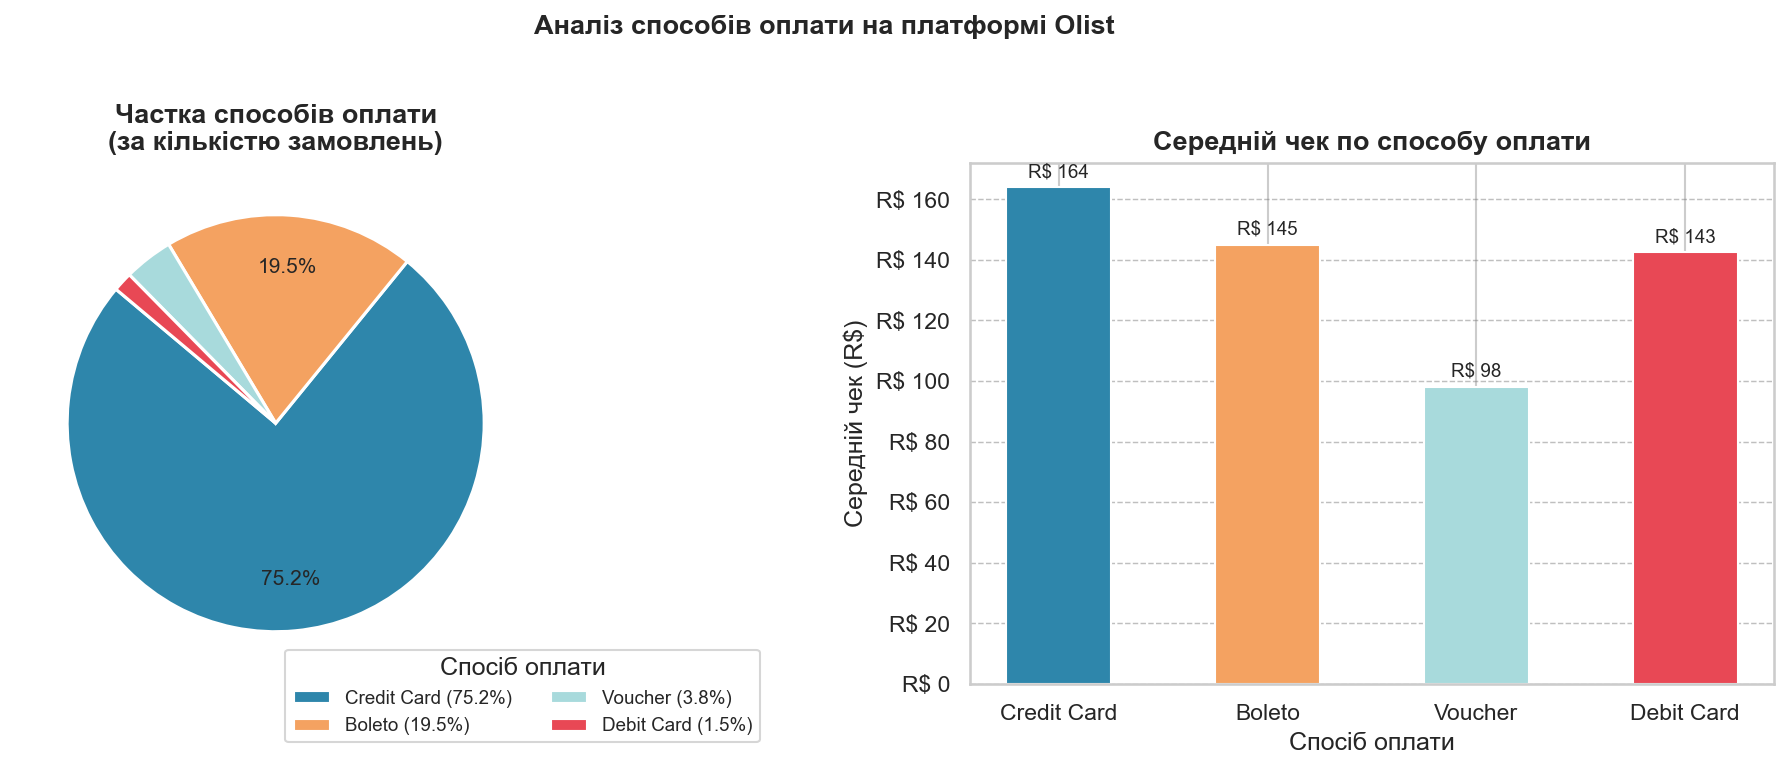

✓ Збережено: chart_06_payment_methods.png


In [7]:
sql_q6 = """
    WITH order_total_by_payment AS (
        SELECT
            order_id,
            payment_type,
            SUM(value) AS order_value
        FROM order_payments
        WHERE payment_type <> 'not_defined'
        GROUP BY order_id, payment_type
    )
    SELECT
        payment_type,
        COUNT(*) AS order_count,
        ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER () * 100, 2) AS share_pct,
        ROUND(AVG(order_value), 2) AS avg_order_value
    FROM order_total_by_payment
    GROUP BY payment_type
    ORDER BY order_count DESC;
"""

df_q6 = pd.read_sql(sql_q6, engine)

labels_map = {
    "credit_card": "Credit Card",
    "boleto": "Boleto",
    "voucher": "Voucher",
    "debit_card": "Debit Card",
}
df_q6["label"] = df_q6["payment_type"].map(labels_map).fillna(df_q6["payment_type"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Лівий — Pie chart
pie_colors = ["#2E86AB", "#F4A261", "#A8DADC", "#E84855"]

def autopct_filter(pct):
    return f"{pct:.1f}%" if pct >= 5 else ""

wedges, texts, autotexts = ax1.pie(
    df_q6["order_count"],
    labels=None,
    autopct=autopct_filter,
    colors=pie_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(10)

# Легенда збоку — читабельно для будь-якої кількості сегментів
legend_labels = [
    f"{row['label']} ({row['share_pct']:.1f}%)" 
    for _, row in df_q6.iterrows()
]

ax1.legend(
    wedges,
    legend_labels,
    title="Спосіб оплати",
    loc="lower left",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    fontsize=9,
)
ax1.set_title("Частка способів оплати\n(за кількістю замовлень)")

# Правий — Bar chart середнього чеку
bars = ax2.bar(
            df_q6["label"], 
            df_q6["avg_order_value"],
            color=pie_colors, 
            edgecolor="white", 
            width=0.5
)
for bar, val in zip(bars, df_q6["avg_order_value"]):
    ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"R$ {val:.0f}", 
            ha="center", 
            va="bottom", 
            fontsize=9
    )

ax2.set_title("Середній чек по способу оплати")
ax2.set_xlabel("Спосіб оплати")
ax2.set_ylabel("Середній чек (R$)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {int(x):,}"))
ax2.grid(True, axis="y", linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

plt.suptitle("Аналіз способів оплати на платформі Olist", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "chart_06_payment_methods.png", bbox_inches="tight")
plt.show()

print("✓ Збережено: chart_06_payment_methods.png")

### Висновок

**Credit Card** домінує — 75.2% усіх замовлень і найвищий середній чек R$ 164, що пояснюється можливістю розстрочки (`installments`), недоступної для інших методів.  
**Boleto** (бразильський банківський платіжний документ, аналог квитанції) займає стабільне друге місце з 19.5% — свідчить про значну частку клієнтів без кредитних карток.  
**Voucher** має найнижчий середній чек R$ 98 — використовується переважно як знижка або доповнення до основного платежу.  
**Debit Card** має мінімальну частку (<1.5%) — у Бразилії дебетові картки рідко застосовуються для онлайн-покупок і тому не виносяться окремо в рекомендації.

---

## Зведений висновок

Шість графіків розкривають три взаємоповʼязані патерни платформи.

**Зростання без утримання.** Платформа зросла у ~20 разів за 2 роки (Графік 1), але плато 2018 тримається виключно за рахунок нових клієнтів — retention близько 3% означає, що кожне замовлення здебільшого від нової людини.

**Логістика як головний ризик.** Більшість штатів мають середній час доставки понад 14 днів (Графік 3), і саме перетин цього порогу обвалює середню оцінку з 4.29 до 3.65 (Графік 5). 27% замовлень потрапляють у критичну зону 15+ днів.

**Концентрація виручки і платіжна чутливість.** Топ-3 категорії дають ~45% доходу топ-10 (Графік 2), і 75% клієнтів обирають кредитну картку — часто через розстрочку (Графік 6). Це сигнал про чутливість до ціни і фінансових інструментів.

Статистичне підтвердження ключових гіпотез (вплив доставки на оцінку, різниця середнього чеку по типах оплати) — у `04_analysis.ipynb`.